# Stage 11 – Reject inference

Every model so far learned only from loans LendingClub **accepted**. The people it turned away never got a loan, so we never see whether they would have repaid. A model trained only on accepted loans has never seen the riskiest part of the applicant population and may underestimate their risk. This is **sample (selection) bias**, and correcting for it with rejected applications is called **reject inference**.

The rejected file only shares a few columns with the accepted file, so this notebook works with those shared features:

| Shared feature | Accepted file | Rejected file |
|---|---|---|
| Loan amount | `loan_amnt` | `Amount Requested` |
| Debt-to-income | `dti` | `Debt-To-Income Ratio` |
| Credit score | `fico_range_low` | `Risk_Score` |
| Employment length | `emp_length` | `Employment Length` |

Steps:

1. compare accepted and rejected applicants,
2. train a baseline model on accepted loans only ("known good/bad"),
3. apply **fuzzy augmentation**: each rejected applicant is added to training twice, once as a default and once as repaid, weighted by their estimated default probability,
4. compare how each model scores the kind of applicants who get rejected.

**Caveat:** rejected applicants have no outcomes, so there is no test set that proves reject inference is "right". The results show how the model changes and how sensitive that is to assumptions, which is how lenders treat it too.

## 1. Load accepted and rejected applicants

In [1]:
import os, gc, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

def first_existing(paths):
    return next((p for p in paths if os.path.exists(p)), paths[0])

ACCEPTED_FILE = first_existing(["../data/accepted_cleaned.csv",
                                r"D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv"])
REJECTED_FILE = first_existing(["../data/rejected_2007_to_2018Q4.csv",
                                r"D:\credit-risk-xai\credit-risk-xai\data\rejected_2007_to_2018Q4.csv"])
SAVE_DIR = "../outputs/notebook11_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
RANDOM_STATE = 42
ACCEPTED_SAMPLE = 200_000
REJECT_FRACTION = 0.015        # share of the ~27M rejected rows to read (about 400k)
print("Accepted:", ACCEPTED_FILE)
print("Rejected:", REJECTED_FILE)

EMP_MAP = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4, "5 years": 5,
           "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9, "10+ years": 10}
FEATURES = ["loan_amnt", "dti", "credit_score", "emp_years"]

def tidy(d):
    d = d.copy()
    for c in ["loan_amnt", "dti", "credit_score"]:
        d[c] = pd.to_numeric(d[c].astype(str).str.replace("%", "", regex=False).str.strip(), errors="coerce")
    d["emp_years"] = d["emp_years"].astype(str).str.strip().map(EMP_MAP)
    d = d[(d["dti"] >= 0) & (d["dti"] <= 100) &
          (d["credit_score"] >= 300) & (d["credit_score"] <= 850) &
          (d["loan_amnt"] > 0)]
    return d.reset_index(drop=True)

# accepted: only the columns we need
acc = pl.read_csv(ACCEPTED_FILE, columns=["loan_amnt", "dti", "fico_range_low", "emp_length", "default"],
                  infer_schema_length=0)
acc = acc.sample(n=min(ACCEPTED_SAMPLE, acc.height), seed=RANDOM_STATE).to_pandas()
acc = acc.rename(columns={"fico_range_low": "credit_score", "emp_length": "emp_years"})
t = acc["default"].astype(str).str.lower().map({"1": 1, "0": 0, "true": 1, "false": 0, "1.0": 1, "0.0": 0})
acc["default"] = t.fillna(0).astype(int)
acc = tidy(acc)
print(f"Accepted loans: {len(acc):,} | default rate {acc['default'].mean():.1%}")

# rejected: stream in chunks and keep a random fraction (the file is ~27M rows)
REJ_COLS = {"Amount Requested": "loan_amnt", "Debt-To-Income Ratio": "dti",
            "Risk_Score": "credit_score", "Employment Length": "emp_years"}
rng = np.random.RandomState(RANDOM_STATE)
parts, total = [], 0
for chunk in pd.read_csv(REJECTED_FILE, usecols=list(REJ_COLS), dtype=str, chunksize=1_000_000):
    total += len(chunk)
    parts.append(chunk[rng.rand(len(chunk)) < REJECT_FRACTION])
    print(f"  read {total:,} rejected rows", end="\r")
rej = tidy(pd.concat(parts, ignore_index=True).rename(columns=REJ_COLS))
del parts
gc.collect()
print(f"\nRejected applications kept (with a credit score and valid DTI): {len(rej):,}")

Accepted: D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv
Rejected: D:\credit-risk-xai\credit-risk-xai\data\rejected_2007_to_2018Q4.csv
Accepted loans: 199,865 | default rate 20.0%
  read 27,648,741 rejected rows
Rejected applications kept (with a credit score and valid DTI): 130,734


## 2. How different are rejected applicants?

              Accepted (median)  Rejected (median)  Accepted missing %  Rejected missing %
loan_amnt               12000.0            10000.0                 0.0                 0.0
dti                        17.6               19.9                 0.0                 0.0
credit_score              690.0              637.0                 0.0                 0.0
emp_years                   6.0                0.0                 5.8                 1.8


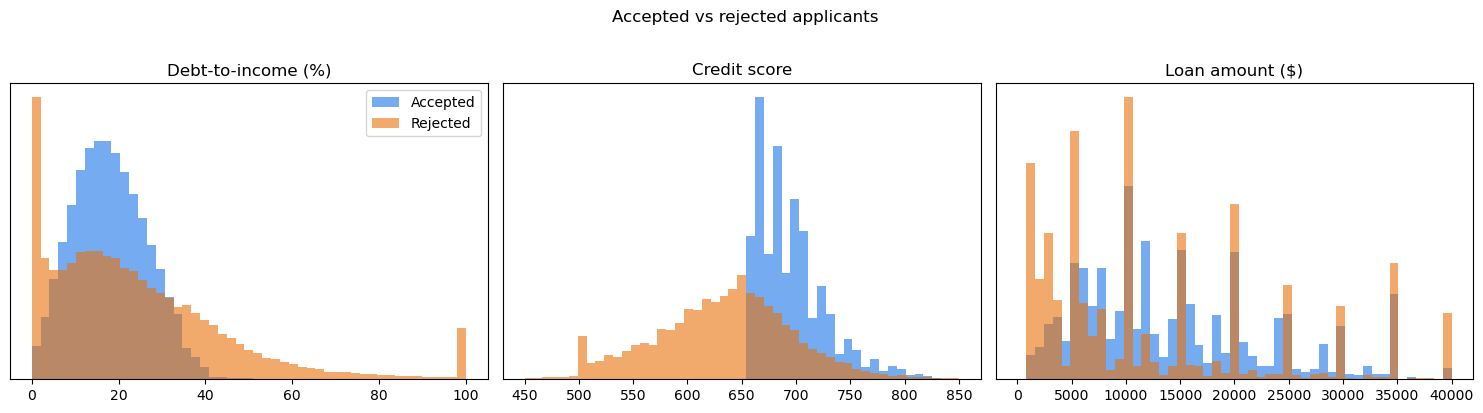


Accept-vs-reject model ROC AUC: 0.991
(close to 1.0 = the two groups look very different, so a model trained on accepted loans only is extrapolating when it scores rejected applicants)


In [2]:
summary = pd.DataFrame({
    "Accepted (median)": acc[FEATURES].median(),
    "Rejected (median)": rej[FEATURES].median(),
    "Accepted missing %": acc[FEATURES].isna().mean() * 100,
    "Rejected missing %": rej[FEATURES].isna().mean() * 100,
}).round(1)
print(summary.to_string())
summary.to_csv(os.path.join(SAVE_DIR, "accepted_vs_rejected_summary.csv"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, label, rng_) in zip(axes, [("dti", "Debt-to-income (%)", (0, 100)),
                                          ("credit_score", "Credit score", (450, 850)),
                                          ("loan_amnt", "Loan amount ($)", (0, 40000))]):
    bins = np.linspace(*rng_, 50)
    ax.hist(acc[col].dropna(), bins=bins, density=True, alpha=0.6, label="Accepted", color="#1a73e8")
    ax.hist(rej[col].dropna(), bins=bins, density=True, alpha=0.6, label="Rejected", color="#e8710a")
    ax.set_title(label)
    ax.set_yticks([])
axes[0].legend()
plt.suptitle("Accepted vs rejected applicants", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "accepted_vs_rejected.png"), dpi=200, bbox_inches="tight")
plt.show()

# How well can the shared features tell accepted from rejected?
both = pd.concat([acc[FEATURES].assign(accepted=1), rej[FEATURES].assign(accepted=0)], ignore_index=True)
tr, te = train_test_split(both, test_size=0.3, random_state=RANDOM_STATE, stratify=both["accepted"])
ar = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, tree_method="hist",
                       random_state=RANDOM_STATE, n_jobs=-1)
ar.fit(tr[FEATURES], tr["accepted"])
print(f"\nAccept-vs-reject model ROC AUC: {roc_auc_score(te['accepted'], ar.predict_proba(te[FEATURES])[:, 1]):.3f}")
print("(close to 1.0 = the two groups look very different, so a model trained on accepted loans only "
      "is extrapolating when it scores rejected applicants)")

## 3. Baseline vs reject-inference models

- **Baseline ("known good/bad")**: trained on accepted loans only.
- **Fuzzy augmentation**: the baseline scores each rejected applicant with a default probability *p*. Each one is added twice: as a default with weight *p*, and as repaid with weight 1 − *p*.
- Rejected applicants are usually riskier than a model trained on accepted loans predicts, so lenders often **inflate** *p* for rejects. The inflation factor multiplies the odds of default. It is an assumption, so three values are compared: 1.0 (none), 1.5 and 2.0.

All models use the same monotonic rules: higher DTI never lowers risk, higher credit score never raises it.

In [3]:
acc_tr, acc_te = train_test_split(acc, test_size=0.2, random_state=RANDOM_STATE, stratify=acc["default"])
rej_aug, rej_eval = train_test_split(rej, test_size=0.5, random_state=RANDOM_STATE)
# use as many rejects for augmentation as half the accepted training set
rej_aug = rej_aug.sample(n=min(len(rej_aug), len(acc_tr) // 2), random_state=RANDOM_STATE)

PARAMS = dict(objective="binary:logistic", tree_method="hist", n_estimators=300, max_depth=4,
              learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
              monotone_constraints="(0,1,-1,0)",   # loan_amnt, dti, credit_score, emp_years
              random_state=RANDOM_STATE, n_jobs=-1)

def train(X, y, w=None):
    m = xgb.XGBClassifier(**PARAMS)
    m.fit(X, y, sample_weight=w)
    return m

baseline = train(acc_tr[FEATURES], acc_tr["default"])
p_rej = baseline.predict_proba(rej_aug[FEATURES])[:, 1]

def inflate(p, k):
    odds = k * p / (1 - p)
    return odds / (1 + odds)

models = {"Baseline (accepted only)": baseline}
for k in [1.0, 1.5, 2.0]:
    pk = inflate(p_rej, k)
    X = pd.concat([acc_tr[FEATURES], rej_aug[FEATURES], rej_aug[FEATURES]], ignore_index=True)
    y = np.concatenate([acc_tr["default"].to_numpy(), np.ones(len(rej_aug)), np.zeros(len(rej_aug))])
    w = np.concatenate([np.ones(len(acc_tr)), pk, 1 - pk])
    models[f"Fuzzy augmentation (x{k:g})"] = train(X, y, w)
    print(f"Trained fuzzy augmentation x{k:g} | assumed reject default rate {pk.mean():.1%}")

Trained fuzzy augmentation x1 | assumed reject default rate 27.2%
Trained fuzzy augmentation x1.5 | assumed reject default rate 35.2%
Trained fuzzy augmentation x2 | assumed reject default rate 41.5%


## 4. Comparison

- **Accepted test ROC AUC**: ranking quality on loans with known outcomes. It should stay roughly the same.
- **Average predicted risk for rejected applicants**: how risky each model thinks the rejected population is.
- **Rejected applicants that would be approved**: using a cut-off that declines the riskiest 20% of *accepted* test applicants, how many of the rejected applicants each model would let through. A model that has learned from rejects should let fewer through.

                    model accepted_test_ROC_AUC avg_risk_accepted avg_risk_rejected cutoff rejected_that_would_be_approved
 Baseline (accepted only)                0.6401             20.0%             27.1%  26.9%                           55.8%
  Fuzzy augmentation (x1)                0.6400             20.0%             27.2%  26.8%                           55.6%
Fuzzy augmentation (x1.5)                0.6383             20.5%             34.1%  27.5%                           37.5%
  Fuzzy augmentation (x2)                0.6363             20.8%             39.6%  28.0%                           20.7%


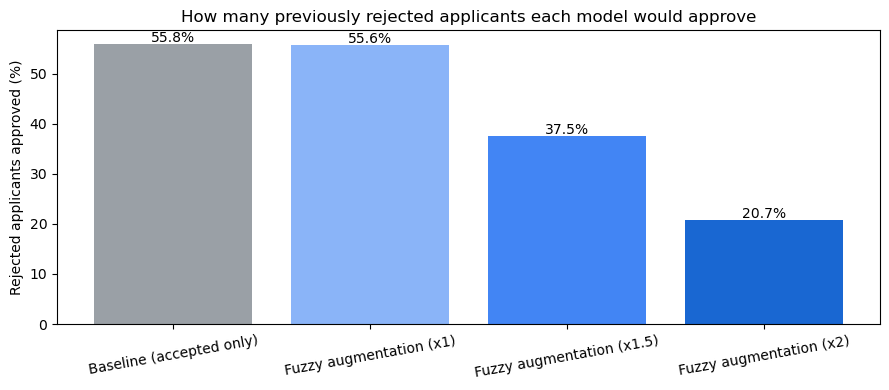

In [4]:
base_te = baseline.predict_proba(acc_te[FEATURES])[:, 1]
rows = []
for name, m in models.items():
    p_acc = m.predict_proba(acc_te[FEATURES])[:, 1]
    p_r = m.predict_proba(rej_eval[FEATURES])[:, 1]
    cutoff = np.quantile(p_acc, 0.80)
    rows.append({"model": name,
                 "accepted_test_ROC_AUC": roc_auc_score(acc_te["default"], p_acc),
                 "avg_risk_accepted": p_acc.mean(),
                 "avg_risk_rejected": p_r.mean(),
                 "cutoff": cutoff,
                 "rejected_that_would_be_approved": (p_r < cutoff).mean()})
comp = pd.DataFrame(rows)
print(comp.to_string(index=False, formatters={
    "accepted_test_ROC_AUC": "{:.4f}".format, "avg_risk_accepted": "{:.1%}".format,
    "avg_risk_rejected": "{:.1%}".format, "cutoff": "{:.1%}".format,
    "rejected_that_would_be_approved": "{:.1%}".format}))
comp.to_csv(os.path.join(SAVE_DIR, "reject_inference_comparison.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#9aa0a6", "#8ab4f8", "#4285f4", "#1967d2"]
ax.bar(comp["model"], comp["rejected_that_would_be_approved"] * 100, color=colors[:len(comp)])
for i, v in enumerate(comp["rejected_that_would_be_approved"]):
    ax.text(i, v * 100 + 0.5, f"{v:.1%}", ha="center")
ax.set_ylabel("Rejected applicants approved (%)")
ax.set_title("How many previously rejected applicants each model would approve")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "rejected_approval_rates.png"), dpi=200)
plt.show()

## 5. What changed inside the model

Average predicted risk as DTI and credit score change, with the other features held at their observed values. The shaded area is where most **accepted** loans sit (5th to 95th percentile). Outside it, the baseline model has very little data and tends to flatten out; reject inference gives it information about that region.

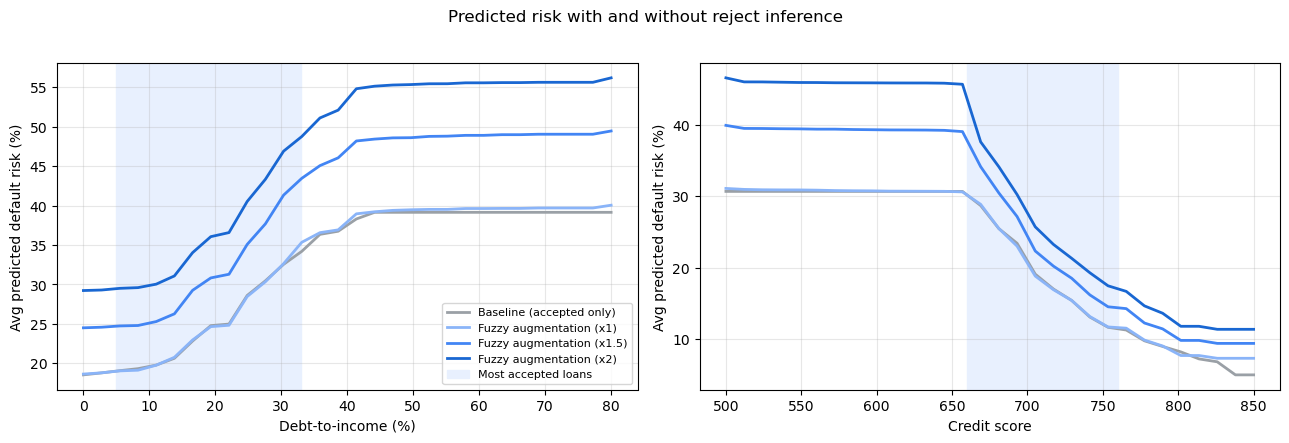

=== Summary ===
Fuzzy augmentation (x1): accepted AUC 0.6400 (baseline 0.6401) | rejected approved 55.6% (baseline 55.8%)
Fuzzy augmentation (x1.5): accepted AUC 0.6383 (baseline 0.6401) | rejected approved 37.5% (baseline 55.8%)
Fuzzy augmentation (x2): accepted AUC 0.6363 (baseline 0.6401) | rejected approved 20.7% (baseline 55.8%)
Outputs saved in: ../outputs/notebook11_outputs


In [5]:
grid_base = rej_eval.sample(n=min(2000, len(rej_eval)), random_state=RANDOM_STATE)[FEATURES]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
styles = {"Baseline (accepted only)": ("#9aa0a6", "-"),
          "Fuzzy augmentation (x1)": ("#8ab4f8", "-"),
          "Fuzzy augmentation (x1.5)": ("#4285f4", "-"),
          "Fuzzy augmentation (x2)": ("#1967d2", "-")}
for ax, (col, label, lo, hi) in zip(axes, [("dti", "Debt-to-income (%)", 0, 80),
                                            ("credit_score", "Credit score", 500, 850)]):
    grid = np.linspace(lo, hi, 30)
    for name, m in models.items():
        curve = []
        for v in grid:
            X = grid_base.copy()
            X[col] = v
            curve.append(m.predict_proba(X)[:, 1].mean())
        c, ls = styles.get(name, ("#000000", "-"))
        ax.plot(grid, np.array(curve) * 100, color=c, linestyle=ls, linewidth=2, label=name)
    a_lo, a_hi = np.nanpercentile(acc[col], [5, 95])
    ax.axvspan(a_lo, a_hi, color="#e8f0fe", zorder=0, label="Most accepted loans")
    ax.set_xlabel(label)
    ax.set_ylabel("Avg predicted default risk (%)")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.suptitle("Predicted risk with and without reject inference", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "reject_inference_partial_dependence.png"), dpi=200, bbox_inches="tight")
plt.show()

print("=== Summary ===")
b = comp.iloc[0]
for _, r in comp.iloc[1:].iterrows():
    print(f"{r['model']}: accepted AUC {r['accepted_test_ROC_AUC']:.4f} (baseline {b['accepted_test_ROC_AUC']:.4f}) | "
          f"rejected approved {r['rejected_that_would_be_approved']:.1%} (baseline {b['rejected_that_would_be_approved']:.1%})")
print("Outputs saved in:", SAVE_DIR)